# Imports

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sspspace
import scipy
from scipy.stats import beta, norm

import nengo
import nengo_dft
from nengo.config import Config
from nengo.ensemble import Ensemble
from nengo.network import Network
from nengo import Node, Connection
from nengo.neurons import LIFRate, Direct
from nengo.synapses import Lowpass, SynapseParam

# Import the basal Ganglia model 
from bg_model import BasalGanglia

# Bundle Creation & Scaling

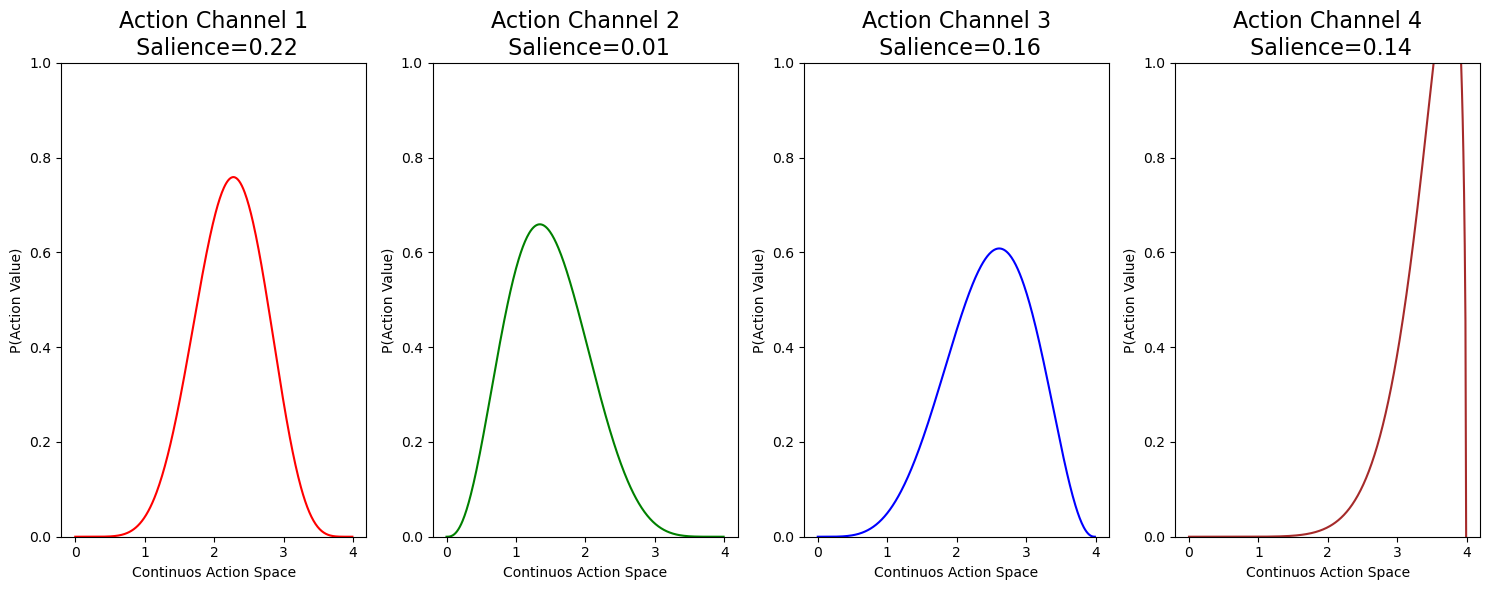

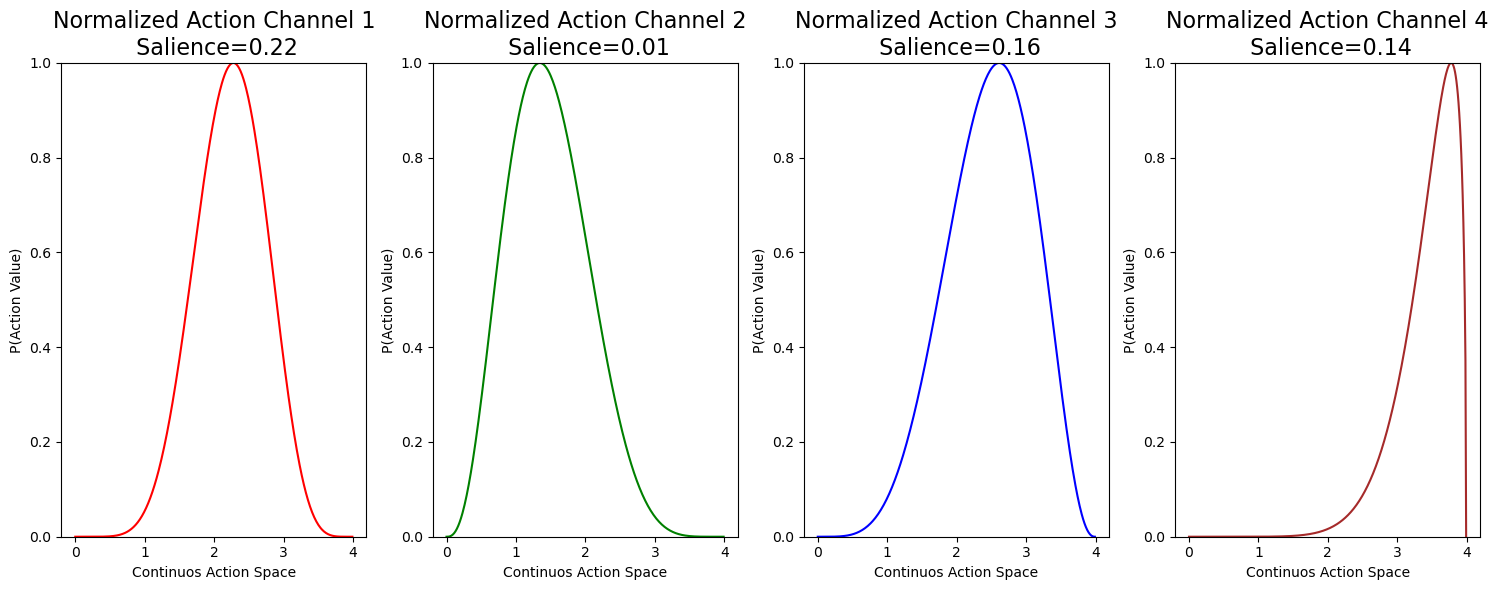

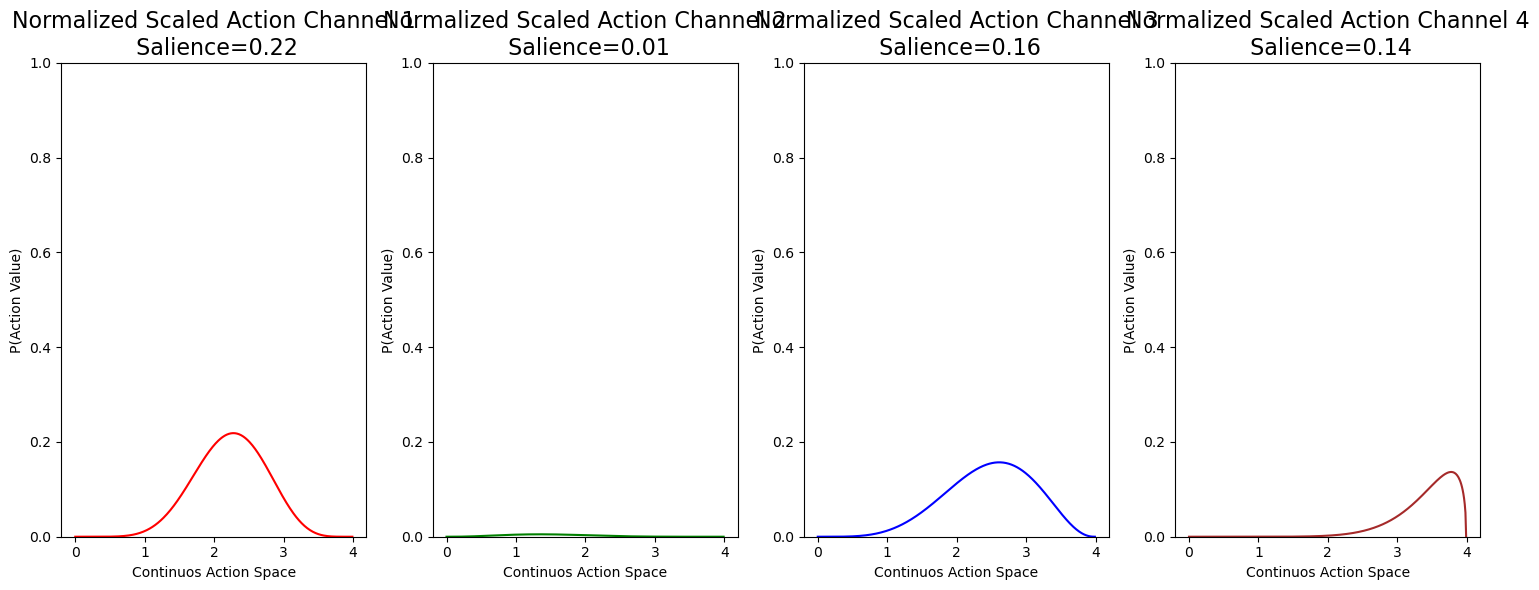

In [34]:
# Domain:  [0, 4]
domain = np.arange(0, 4, 0.01).reshape(-1, 1) # Shape: (400, 1)
# from sspspace.encoders import RandomSSPSpace  
from sspspace.sspspace.encoders import RandomSSPSpace
# SSP encoder
ssp_encoder = RandomSSPSpace(
    domain_dim = 1, # scalar action values
    ssp_dim = 512, # high dimensional SSPs
    rng=np.random.RandomState(), 
    length_scale=0.5
)

# Convert scalar action values into high dimensional SSPs
domain_phis = ssp_encoder.encode(domain) # Shape: (400, 512)

# Place cell encoders for Nengo ensembles
low = 0
high = 4
width = high - low
places_ = np.arange(low, high, width/(domain.shape[0]))
encoders = np.asarray(ssp_encoder.encode(places_.reshape(-1, 1))).squeeze()

# Create distributions 
n_actions = 4 # Number of action channels in the BG model 
seed = 20889604
rng = np.random.RandomState(seed)
# Randomly sample a's and b's to create distributions 
a_s = np.random.uniform(low = 1, high = 10, size = n_actions)
b_s = np.random.uniform(low = 1, high = 10, size = n_actions)

beta_distributions = []

for i in range(n_actions):
    # Beta PDF over domain 
    beta_pdfs = beta.pdf(domain, a_s[i], b_s[i], scale=domain[-1]) # Shape: (400, 1)
    beta_distributions.append(beta_pdfs)

# ---------------------------
# Helper functions 
# --------------------------

def to_bundle(bundles, domain_phis):
    '''
    Convert distributions to 512D bundles.
    Parameters:
    - bundles: List of vectors representing a distribution over a domain space
    Returns:
    - b: List of vectors representing a set of 512-dimensional SSP version of the distribution supplied. 
    '''
    b = []
    for i in range(len(bundles)):
        bun = np.einsum('n,nd->d', bundles[i].squeeze(), domain_phis)
        b.append(bun)
    return b

def to_scale(scales, vectors):
    '''
    Scales the vectors by a numeric value 
    Parameters:
    - scales: list of floating point numbers 
    - vectors: list of vectors to be scaled 
    Returns:
    - scaled: a list of vectors scaled by a numeric scalar value
    '''
    scaled = []
    for i in range(len(scales)):
        scaled.append(scales[i] * vectors[i])
    return scaled

def to_normalize(vectors):
   '''
   Takes in a list of vectors and scales them to all have their peaks at 1. 
   '''
   return vectors / np.max(vectors, axis=1, keepdims=True)


# Scale by salience
salience = np.random.uniform(low = 0, high = 1, size = n_actions)

# Plot the Distributions
colors = ['red', 'green', 'blue', 'brown']
fig, axs = plt.subplots(1, n_actions, figsize=(15, 6))
for i in range(n_actions):
    axs[i].plot(domain, beta_distributions[i], color=colors[i])
    axs[i].set_title(f'Action Channel {i + 1}\n Salience={salience[i]:.2f}', fontsize=16)
    axs[i].set_xlabel("Continuos Action Space")
    axs[i].set_ylabel("P(Action Value)")
    axs[i].set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Plot the normalized version of the distributions
normalized_distributions = to_normalize(beta_distributions)
fig, axs = plt.subplots(1, n_actions, figsize=(15, 6))
for i in range(n_actions):
    axs[i].plot(domain, normalized_distributions[i], color=colors[i])
    axs[i].set_title(f'Normalized Action Channel {i + 1}\n Salience={salience[i]:.2f}', fontsize=16)
    axs[i].set_xlabel("Continuos Action Space")
    axs[i].set_ylabel("P(Action Value)")
    axs[i].set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Plot the scaled (by salience) version of the distributions
scaled_norm_dist = to_scale(salience, to_normalize(beta_distributions))
fig, axs = plt.subplots(1, n_actions, figsize=(15, 6))
for i in range(n_actions):
    axs[i].plot(domain, scaled_norm_dist[i], color=colors[i])
    axs[i].set_title(f'Normalized Scaled Action Channel {i + 1}\n Salience={salience[i]:.2f}', fontsize=16)
    axs[i].set_xlabel("Continuos Action Space")
    axs[i].set_ylabel("P(Action Value)")
    axs[i].set_ylim(0, 1)
plt.tight_layout()
plt.show()


## DNF Parameters

In [35]:
dnf_params = {'h'       : -3.009416816439706,
            'global_inh'      : 8.641108231311897,
            'tau'             : 0.04706404390267922,
            'exc'             : 9.421285790349613,
            'inh'             : 1.4841093480380807,
            'exc_w'           : 8.534993467227224,
            'inh_w'           : 4.748154014869723,
            'dt'              : 0.001, 
            'c_noise'         : 1.0,
            'shape'           : [(n_actions, 400)], 
            'beta'            : 4,
    }

# Build the Basal Ganglia Model

In [36]:
# 3). DNF/BG Parameters
d1_weight = 1.0
d2_weight = 1.0
dopamine_level = 0.2

model = nengo.Network(label='One DNF BG')
input_bundle = to_bundle(to_scale(salience, to_normalize(beta_distributions)), domain_phis=domain_phis)
with model:

    input_bundle_nodes = []
    for i in range(n_actions):
        cortical_bundle = nengo.Node(nengo.processes.PresentInput(inputs=[input_bundle[i]], presentation_time=1.5), 
                                     label =f'ssp_cortical_bundle_node_{i}')
        input_bundle_nodes.append(cortical_bundle)
    
    # Dopamine Node
    dopamine_node = nengo.Node(nengo.processes.PresentInput(inputs=[dopamine_level], presentation_time=1.5), 
                               label='dopamine_node')

    # BG Model
    bg_model = BasalGanglia(n_actions=n_actions, dnf_parameters=dnf_params, encoders=encoders)

    # Output node
    out_node = Node(size_in = 512 * n_actions)

    # COnnections 
    Connection(dopamine_node, bg_model.dopamine, synapse=None)
    for i in range(n_actions):
        # Connect input nodes to Basal Ganglia's Cortex Input
        Connection(input_bundle_nodes[i], bg_model.cortex_inputs[i], synapse=None)
    Connection(bg_model.bg_out, out_node, synapse=None)

    # Probes
    p_ins = []
    for i in range(n_actions):
        p_in = nengo.Probe(input_bundle_nodes[i], synapse=None)
        p_ins.append(p_in)
    
    p_dnf_in_d1 = nengo.Probe(bg_model.d1_dnf.g.neurons, 'input', synapse = None)
    p_dnf_neurons_d1= nengo.Probe(bg_model.d1_dnf.g.neurons, synapse=None)
    p_g_d1 = nengo.Probe(bg_model.d1_dnf.g, synapse=None)

    p_dnf_in_d2 = nengo.Probe(bg_model.d2_dnf.g.neurons, 'input', synapse = None)
    p_dnf_neurons_d2= nengo.Probe(bg_model.d2_dnf.g.neurons, synapse=None)
    p_g_d2 = nengo.Probe(bg_model.d2_dnf.g, synapse=None)

    p_out = nengo.Probe(out_node, synapse = None)

with nengo.Simulator(model) as sim:
    sim.run(1.5)

TypeError: DNF.make_dnf() got multiple values for argument 'shape'

## Plotting

### Input to Basal Ganglia Model

In [ ]:
inp_dec = []
for i in range(n_actions):
    seg_in = sim.data[p_ins[i]][-1] # Shape: (512, 1)
    inp_dec_uni = np.einsum('d,nd->n', seg_in, domain_phis)
    inp_dec.append(inp_dec_uni)

#7). Plot N channel side by side, each with twin y axes
fig, axes = plt.subplots(
    1, n_actions,
    figsize=(5 * n_actions, 4),
    sharex=True
)

# If you only have one action, axes will not be a list
if n_actions == 1:
    axes = [axes]


for i, ax in enumerate(axes):
    # primary y-axis: input distribution
    ax.plot(domain.squeeze(), beta_distributions[i],
            ls='--', color="#007e74",
            label="input dist")
    ax.set_xlabel("Action Domain", fontsize="xx-large")
    ax.set_ylabel("$S_c(x,y)$ Input Dist", fontsize="xx-large")
    ax.tick_params(axis='x', labelsize='x-large')
    ax.tick_params(axis='y', labelsize='x-large')

    # secondary y-axis: output distribution
    ax2 = ax.twinx()
    ax2.plot(domain.squeeze(), inp_dec[i],
             ls='-', color="#ffaa00",
             label="output dist")
    ax2.tick_params(axis='y', labelsize='x-large')

    # combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2,
              loc='upper right', fontsize='x-large')
    ax.set_title(f'Action Channel {i + 1}\n Salience={salience[i]: .2f}')

plt.tight_layout()
plt.show()


### D1 & D2 DNF 

NameError: name 'sim' is not defined

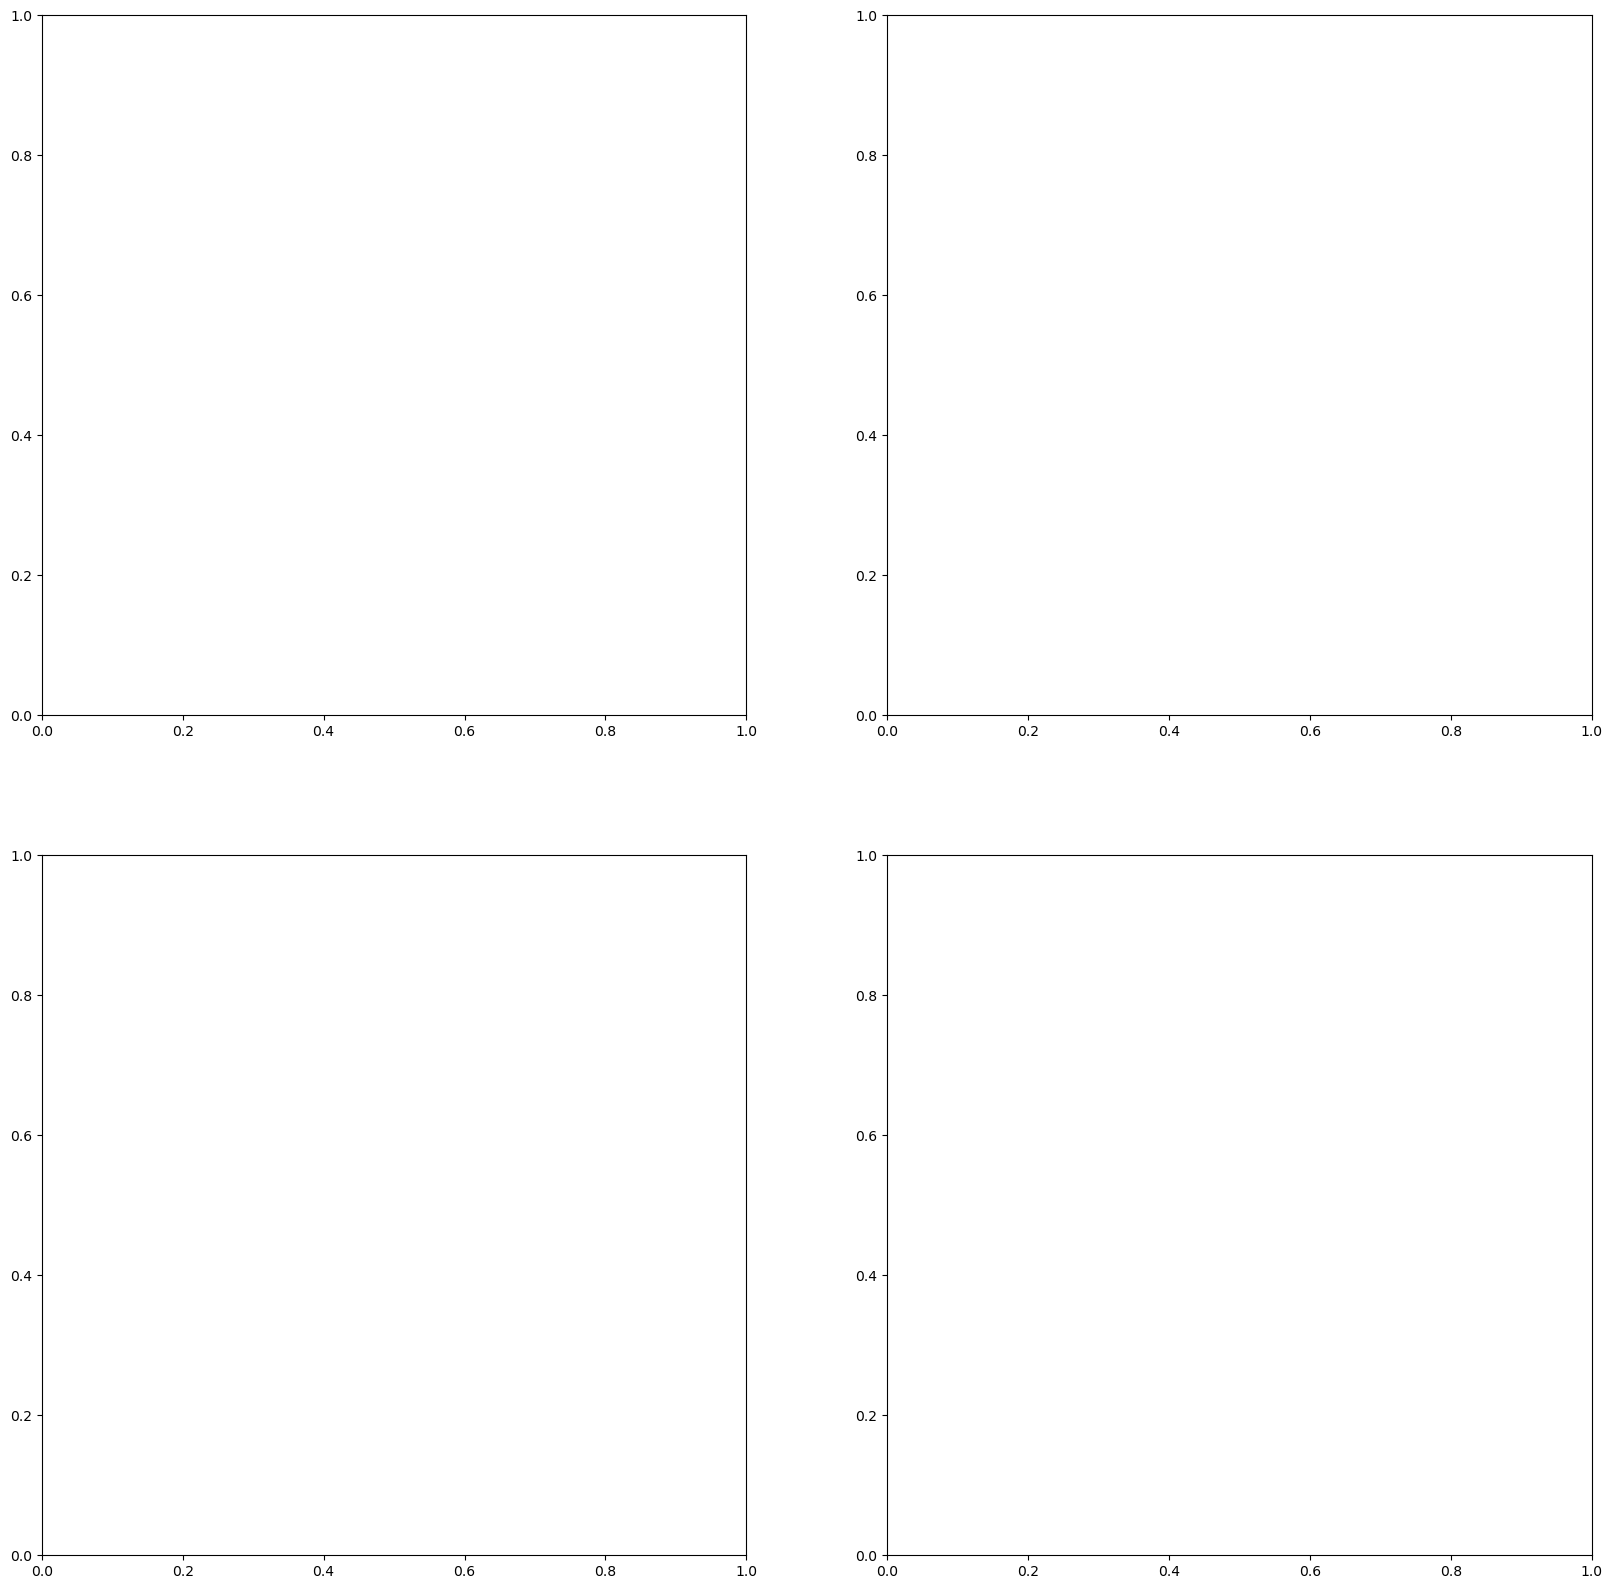

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(20, 20),)
# D1
# D1 Input to DNF
axes[0,0].plot(sim.data[p_dnf_in_d1][-1])
axes[0,0].title("DNF D1 input ")
# D1 Neuron Activities
axes[0,1].plot(sim.data[p_dnf_neurons_d1][-1])
axes[0,1].title("DNF D1 neuron activities " )

# D2
# D2 Input to DNF
axes[1,0].plot(sim.data[p_dnf_in_d2][-1])
axes[1,0].title("DNF D2 input")
# D2 Neuron activities 
axes[1,1].plot(sim.data[p_dnf_neurons_d2][-1])
axes[1,1].title("DNF D2 neuron activities" )

plt.tight_layout()
plt.show()